In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgba
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
from matplotlib.collections import LineCollection
from matplotlib.legend_handler import HandlerBase
import imageio

# --- Setup: Logo, Palettes, and Helper Functions ---
try:
    logo_arr = mpimg.imread("/home/pantheon/drea/neural_mpc/semantic_mpc/tools/plots/sun_orientation.png")
except FileNotFoundError:
    print("Logo file not found, creating a placeholder.")
    logo_arr = np.zeros((10, 10, 4))

paired_palette = sns.color_palette("Paired")
dark_paired_palette = sns.color_palette("dark")

def get_latest_csv(mode, directory, suffix="plot_data.csv"):
    pattern = os.path.join(directory, f"{mode}*{suffix}")
    files = glob.glob(pattern)
    return max(files, key=os.path.getmtime) if files else None

class HandlerGradient(HandlerBase):
    def __init__(self, cmap, num_stripes=64, **kw):
        super().__init__(**kw)
        self.cmap = cmap
        self.num_stripes = num_stripes
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        gradient = np.linspace(0, 1, self.num_stripes)
        colors = self.cmap(gradient)
        stripes = []
        for i in range(self.num_stripes):
            stripe = mpatches.Rectangle([xdescent + i * width / self.num_stripes, ydescent],
                                        width / self.num_stripes, height,
                                        fc=colors[i], transform=trans, edgecolor='none')
            stripes.append(stripe)
        return stripes

class HandlerImage(HandlerBase):
    def __init__(self, image_arr, zoom=1.0, **kw):
        super().__init__(**kw)
        self.image_arr = image_arr
        self.zoom = zoom
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        imagebox = OffsetImage(self.image_arr, zoom=self.zoom)
        ab = AnnotationBbox(imagebox, (xdescent + 0.5 * width, ydescent + 0.5 * height),
                            frameon=False, xycoords=trans, box_alignment=(0.5, 0.5), pad=0)
        return [ab]

def load_csv_data(csv_path):
    with open(csv_path, 'r') as f:
        first_line = f.readline().strip()
    parts = first_line.split(',')
    if parts[0] == "tree_positions":
        tree_positions_list = [float(x) for x in parts[1:] if x]
        tree_positions = np.array(tree_positions_list).reshape(len(tree_positions_list) // 2, 2) if tree_positions_list else np.array([]).reshape(0,2)
    else:
        tree_positions = None
    df = pd.read_csv(csv_path, skiprows=2)
    return (
        df["time"].values,
        df["x"].values,
        df["y"].values,
        df["theta"].values,
        df["entropy"].values,
        df[[col for col in df.columns if col.startswith("lambda_")]].values,
        tree_positions
    )

def plot_trajectory_subplot(ax, x, y, theta, trees, lambda_history, custom_cmap,
                            tick_label_fontsize, subplot_title_fontsize, mode_label_for_title,
                            xlim, ylim):
    ax.plot(x, y, marker='o', color='orange', linewidth=1.0, markersize=1.0, label="Trajectory")
    ax.scatter(x[0], y[0], color='crimson', s=150, marker='X', label="Initial Position", zorder=4)
    ax.scatter(x[-1], y[-1], color='gold', s=150, marker='*', label="Final Position", zorder=4)

    if trees is not None and trees.size > 0:
        for i in range(trees.shape[0]):
            final_lambda = lambda_history[-1, i] if lambda_history.shape[1] > i else 0.5
            tree_color = custom_cmap(final_lambda)
            ax.scatter(trees[i, 0], trees[i, 1], color=tree_color, s=100, marker='o', zorder=3)

    step = max(1, len(x) // 100)
    for idx_arr in range(0, len(x), step):
        x0, y0, t = x[idx_arr], y[idx_arr], theta[idx_arr]
        x1 = x0 + 1.5 * np.cos(t)
        y1 = y0 + 1.5 * np.sin(t)
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle="->", color="orange", linewidth=1.5))

    ax.tick_params(axis='both', labelsize=tick_label_fontsize)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(mode_label_for_title, fontsize=subplot_title_fontsize)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(5))

def plot_entropy_subplot(ax, time_history, entropy, label, color, axis_label_fontsize, tick_label_fontsize):
    ax.plot(time_history, entropy, linewidth=1.5, markersize=1.0, label=label, color=color)
    ax.set_xlabel("Time (s)", fontsize=axis_label_fontsize)
    ax.set_ylabel("Entropy", fontsize=axis_label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_label_fontsize)

def apply_offset_if_needed(mode, data_dict):
    """If mode is 'mpc' and trees exist, shift whole scene so first tree ends at (0,0)."""
    if mode != "mpc":
        return data_dict
    trees = data_dict.get('trees', None)
    if trees is None or trees.size == 0:
        return data_dict
    t0x, t0y = trees[0, 0], trees[0, 1]
    offx, offy = -t0x, -t0y
    trees_shifted = trees.copy()
    trees_shifted[:, 0] += offx
    trees_shifted[:, 1] += offy
    x_shifted = data_dict['x'] + offx
    y_shifted = data_dict['y'] + offy
    out = data_dict.copy()
    out['trees'] = trees_shifted
    out['x'] = x_shifted
    out['y'] = y_shifted
    return out

def trim_tail_by_seconds(data_dict, seconds_to_trim):
    """Trim the tail of series by a time delta (seconds)."""
    t = data_dict['time']
    if t is None or len(t) == 0 or seconds_to_trim <= 0:
        return data_dict
    cutoff = t[-1] - seconds_to_trim
    if cutoff <= t[0]:
        idx_end = 1  # keep at least the first sample to avoid empty arrays
    else:
        idx_end = np.searchsorted(t, cutoff, side='right')
        idx_end = max(1, min(idx_end, len(t)))  # clamp
    out = data_dict.copy()
    out['time']    = data_dict['time'][:idx_end]
    out['x']       = data_dict['x'][:idx_end]
    out['y']       = data_dict['y'][:idx_end]
    out['theta']   = data_dict['theta'][:idx_end]
    out['entropy'] = data_dict['entropy'][:idx_end]
    if 'lambda_h' in data_dict and data_dict['lambda_h'] is not None and data_dict['lambda_h'].size:
        out['lambda_h'] = data_dict['lambda_h'][:idx_end, :]
    return out

def compute_global_bounds(data_cache, pad_ratio=0.05):
    xs = np.concatenate([d['x'] for d in data_cache.values()]) if data_cache else np.array([0,1])
    ys = np.concatenate([d['y'] for d in data_cache.values()]) if data_cache else np.array([0,1])
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    x_pad = max(1e-6, (x_max - x_min) * pad_ratio)
    y_pad = max(1e-6, (y_max - y_min) * pad_ratio)
    return (x_min - x_pad, x_max + x_pad, y_min - y_pad, y_max + y_pad)

# --- Main Configuration ---
modes = ["greedy", "linear", "mower_fast", "mower_slow", "mpc"]
baselines_dir = "../plots/new_figure/"

# Font sizes
axis_label_fontsize = 15
tick_label_fontsize = 14
subplot_title_fontsize = 18
legend_fontsize = 14
suptitle_fontsize = 22

# Colormap and labels
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap", [paired_palette[3], (0.5, 0.5, 0.5), dark_paired_palette[1]]
)
algorithm_labels = {
    "greedy": "Greedy Approach",
    "linear": "Linear Path",
    "mower_fast": "Fast Mower",
    "mower_slow": "Slow Mower",
    "mpc": "Neural IPP MPC",
}
colors = sns.color_palette("tab10", len(modes))
mode_colors = {mode: colors[i] for i, mode in enumerate(modes)}

# Animation params
FPS = 15
FADE_LENGTH = 50
ENTROPY_WINDOW = 20.0  # seconds; set to None for full range in GIF

# --- 1. Generate Static Multi-mode Comparison Plot ---
print("--- Generating Static Comparison Plot ---")
fig = plt.figure(figsize=(16, 7.5))
gs = GridSpec(2, 4, figure=fig, width_ratios=[1,1,1,1], height_ratios=[1,1], wspace=0.25, hspace=0.35)

any_trees = False
data_cache = {}

# Load data and preprocess
for i, mode in enumerate(modes):
    csv_file = get_latest_csv(mode, baselines_dir)
    if not csv_file:
        print(f"Warning: No CSV found for mode '{mode}'. Skipping.")
        continue
    try:
        time_h, x, y, theta, entropy, lambda_h, trees = load_csv_data(csv_file)
        data_cache[mode] = {'time': time_h, 'x': x, 'y': y, 'theta': theta,
                            'entropy': entropy, 'lambda_h': lambda_h, 'trees': trees}

        if mode == "mower_fast":
            data_cache[mode] = trim_tail_by_seconds(data_cache[mode], 45.0)
        elif mode == "mower_slow":
            data_cache[mode] = trim_tail_by_seconds(data_cache[mode], 90.0)

        if data_cache[mode]['trees'] is not None and data_cache[mode]['trees'].size > 0:
            any_trees = True
    except Exception as e:
        print(f"Error loading or processing {csv_file}: {e}")
        continue

# Compute global bounds for consistent view
x_min, x_max, y_min, y_max = compute_global_bounds(data_cache)

# Plot trajectory subplots
for i, mode in enumerate(modes):
    if mode not in data_cache:
        continue
    if i < 4:
        ax_t = fig.add_subplot(gs[0, i])
    else:
        ax_t = fig.add_subplot(gs[1, 0])

    label = algorithm_labels.get(mode, mode.capitalize())
    plot_trajectory_subplot(
        ax_t,
        data_cache[mode]['x'],
        data_cache[mode]['y'],
        data_cache[mode]['theta'],
        data_cache[mode]['trees'],
        data_cache[mode]['lambda_h'],
        custom_cmap,
        tick_label_fontsize, subplot_title_fontsize, label,
        (x_min, x_max), (y_min, y_max)
    )
    oim = OffsetImage(logo_arr, zoom=0.045)
    ab = AnnotationBbox(oim, (-0.01, 0.99), xycoords="axes fraction", frameon=False)
    ax_t.add_artist(ab)

# Entropy subplot spanning three columns
ax_entropy = fig.add_subplot(gs[1, 1:4])
for i, mode in enumerate(modes):
    if mode not in data_cache:
        continue
    data = data_cache[mode]
    label = algorithm_labels.get(mode, mode.capitalize())
    plot_entropy_subplot(ax_entropy, data['time'], data['entropy'], label, mode_colors[mode],
                         axis_label_fontsize, tick_label_fontsize)
    ax_entropy.axvline(x=data['time'][-1], color=mode_colors[mode], linestyle='--', linewidth=1.5)

# Max duration (prefer MPC if present)
if 'mpc' in data_cache:
    max_duration = data_cache['mpc']['time'][-1]
    print(f"MPC found. Max duration = {max_duration:.2f}s")
else:
    print("Warning: 'mpc' data not found. Using max duration of all available modes as fallback.")
    max_duration = max((data['time'][-1] for data in data_cache.values()), default=0)

# Finalize legends and layout for static plot
legend_handles = [
    Line2D([0], [0], color='orange', lw=1.5, marker='o', markersize=2, label='Trajectory'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='crimson', markersize=15, label='Initial Position'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=25, label='Final Position')
]
legend_labels = ['Trajectory', 'Initial Position', 'Final Position']
image_handle = mpatches.Patch(color='none')
legend_handles.append(image_handle)
legend_labels.append('Sun Direction')
handler_map = {image_handle: HandlerImage(logo_arr, zoom=0.04)}
if any_trees:
    grad_handle = mpatches.Patch(color='none')
    legend_handles.append(grad_handle)
    legend_labels.append('Belief: low → mid → high')
    handler_map[grad_handle] = HandlerGradient(cmap=custom_cmap)

fig.legend(handles=legend_handles, labels=legend_labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.05), ncol=5, fontsize=legend_fontsize, handler_map=handler_map)
ax_entropy.set_title("Entropy Comparison", fontsize=subplot_title_fontsize)
ax_entropy.set_xlim(0, max_duration)
ax_entropy.legend()
ax_entropy.grid(True, linestyle='--', alpha=0.7)

# Save static outputs (PNG + SVG)
output_path_static_png = os.path.join(baselines_dir, "multimode_comparison.png")
output_path_static_svg = os.path.join(baselines_dir, "multimode_comparison.svg")
fig.savefig(output_path_static_png, dpi=350, bbox_inches='tight')
fig.savefig(output_path_static_svg, bbox_inches='tight')
print(f"Static plots saved to {output_path_static_png} and {output_path_static_svg}")
plt.close(fig)


--- Generating Static Comparison Plot ---
MPC found. Max duration = 255.12s
Static plots saved to ../plots/new_figure/multimode_comparison.png and ../plots/new_figure/multimode_comparison.svg


In [ ]:

# --- 2. Generate GIF Animation for Multi-Mode Comparison ---
print("\n--- Generating Multi-Mode Animation GIF ---")
if not data_cache:
    print("No data loaded, cannot generate GIF.")
else:
    output_gif_path = os.path.join(baselines_dir, "multimode_animation.gif")

    time_step = 10.0 / FPS
    animation_times = np.arange(0, max_duration, time_step)
    print(f"Frames: {len(animation_times)} | dt={time_step:.3f}s | FPS={FPS}")

    # Figure + Canvas (no Pillow, no savefig per frame)
    from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
    fig_gif = plt.figure(figsize=(16, 7.5))
    canvas = FigureCanvas(fig_gif)
    gs_gif = GridSpec(2, 4, figure=fig_gif, width_ratios=[1,1,1,1], height_ratios=[1,1], wspace=0.25, hspace=0.35)

    axs_traj_gif = {}
    for i, mode in enumerate(modes):
        if mode not in data_cache:
            continue
        axs_traj_gif[mode] = fig_gif.add_subplot(gs_gif[0, i] if i < 4 else gs_gif[1, 0])
    ax_entropy_gif = fig_gif.add_subplot(gs_gif[1, 1:4])

    # writer incrementale
    with imageio.get_writer(output_gif_path, mode='I', fps=FPS) as writer:
        for t_current in animation_times:
            # clear axes
            ax_entropy_gif.cla()
            for ax in axs_traj_gif.values():
                ax.cla()

            # draw all subplots
            for i, mode in enumerate(modes):
                if mode not in data_cache:
                    continue
                data = data_cache[mode]
                ax_t = axs_traj_gif[mode]

                # indice temporale robusto
                tarr = data['time']
                if t_current <= tarr[0]:
                    k = 0
                else:
                    k = np.searchsorted(tarr, t_current, side='right') - 1
                    k = max(0, min(k, len(tarr) - 1))

                # limiti coerenti con lo statico
                ax_t.set_aspect('equal', adjustable='box')
                ax_t.set_xlim(x_min, x_max)
                ax_t.set_ylim(y_min, y_max)
                ax_t.set_title(algorithm_labels.get(mode, mode.capitalize()), fontsize=subplot_title_fontsize-2)
                ax_t.xaxis.set_major_locator(MultipleLocator(5))
                ax_t.yaxis.set_major_locator(MultipleLocator(5))
                ax_t.tick_params(axis='both', labelsize=tick_label_fontsize-2)

                # alberi colorati
                if data['trees'] is not None and data['trees'].size > 0:
                    for tree_idx in range(data['trees'].shape[0]):
                        current_lambda = data['lambda_h'][k, tree_idx] if data['lambda_h'].shape[1] > tree_idx else 0.5
                        ax_t.scatter(data['trees'][tree_idx, 0], data['trees'][tree_idx, 1],
                                     color=custom_cmap(current_lambda), s=100, marker='o', zorder=3)

                # start marker
                ax_t.scatter(data['x'][0], data['y'][0], color='crimson', s=150, marker='X', zorder=4)

                # traiettoria con fade
                points = np.array([data['x'][:k+1], data['y'][:k+1]]).T.reshape(-1, 1, 2)
                if len(points) >= 2:
                    segments = np.concatenate([points[:-1], points[1:]], axis=1)
                    num_segments = len(segments)
                    base_color = to_rgba('orange')
                    segment_colors = np.tile(base_color, (num_segments, 1))
                    fade_start_idx = max(0, num_segments - FADE_LENGTH)
                    alphas = np.linspace(0.2, 1.0, num_segments - fade_start_idx)
                    if (num_segments - fade_start_idx) > 0:
                        segment_colors[fade_start_idx:, 3] = alphas
                    if num_segments > FADE_LENGTH:
                        segment_colors[:fade_start_idx, 3] = 0.2
                    lc = LineCollection(segments, colors=segment_colors, linewidths=1.5)
                    ax_t.add_collection(lc)

                # head marker
                ax_t.scatter(data['x'][k], data['y'][k], color='darkorange', s=100, zorder=5)

                # entropia
                ax_entropy_gif.plot(data['time'][:k+1], data['entropy'][:k+1],
                                    color=mode_colors[mode], linewidth=2,
                                    label=algorithm_labels.get(mode, mode.capitalize()))
                ax_entropy_gif.scatter(data['time'][k], data['entropy'][k],
                                       color=mode_colors[mode], s=50, zorder=5)

            # titolo e griglia
            ax_entropy_gif.set_title("Entropy Comparison", fontsize=subplot_title_fontsize)
            ax_entropy_gif.set_xlabel("Time (s)", fontsize=axis_label_fontsize)
            ax_entropy_gif.set_ylabel("Entropy", fontsize=axis_label_fontsize)
            ax_entropy_gif.legend(loc='lower left', fontsize=tick_label_fontsize-2)
            ax_entropy_gif.grid(True, linestyle='--', alpha=0.7)

            # --- Dynamic x-limits for entropy (sliding window) ---
            if ENTROPY_WINDOW is not None and ENTROPY_WINDOW > 0:
                t0 = max(0.0, t_current - ENTROPY_WINDOW)
                t1 = max(t_current, t0 + 1e-3)
                ax_entropy_gif.set_xlim(t0, min(max_duration, t1))
            else:
                ax_entropy_gif.set_xlim(0, max_duration)
            ax_entropy_gif.xaxis.set_major_locator(MultipleLocator(5))

            # tempo mostrato una sola volta (suptitle del frame)
            fig_gif.suptitle(f"t = {t_current:.1f}s", fontsize=suptitle_fontsize)

            # RENDER → BUFFER RGBA (no PNG, no Pillow)
            fig_gif.canvas.draw()
            w, h = fig_gif.canvas.get_width_height()
            buf = np.frombuffer(fig_gif.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)
            frame_rgb = buf[:, :, :3].copy()
            writer.append_data(frame_rgb)

    plt.close(fig_gif)
    print(f"Successfully generated and saved GIF to {output_gif_path}")

# --- 3. Display Static Plot ---
print("\nDisplaying final static plot...")
try:
    display_img = plt.imread(output_path_static_png)
    fig_display, ax_display = plt.subplots(figsize=(16, 8.5))
    ax_display.imshow(display_img)
    ax_display.axis('off')
    plt.show()
except (NameError, FileNotFoundError):
    print("Could not display static plot as it was not generated or found.")



--- Generating MPC trees-only transparent video (1:1) ---
[Trees-only] eff_frames=1079, target=99.0s -> FPS=5.000000
0.0917516218721038
WEBM (VP9+alpha) not available (The `FFMPEG` plugin is not installed. Use `pip install imageio[ffmpeg]` to install it.). Will export PNG frames only.


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7fabc6b91790> (for post_execute), with arguments args (),kwargs {}:


IndexError: list index out of range

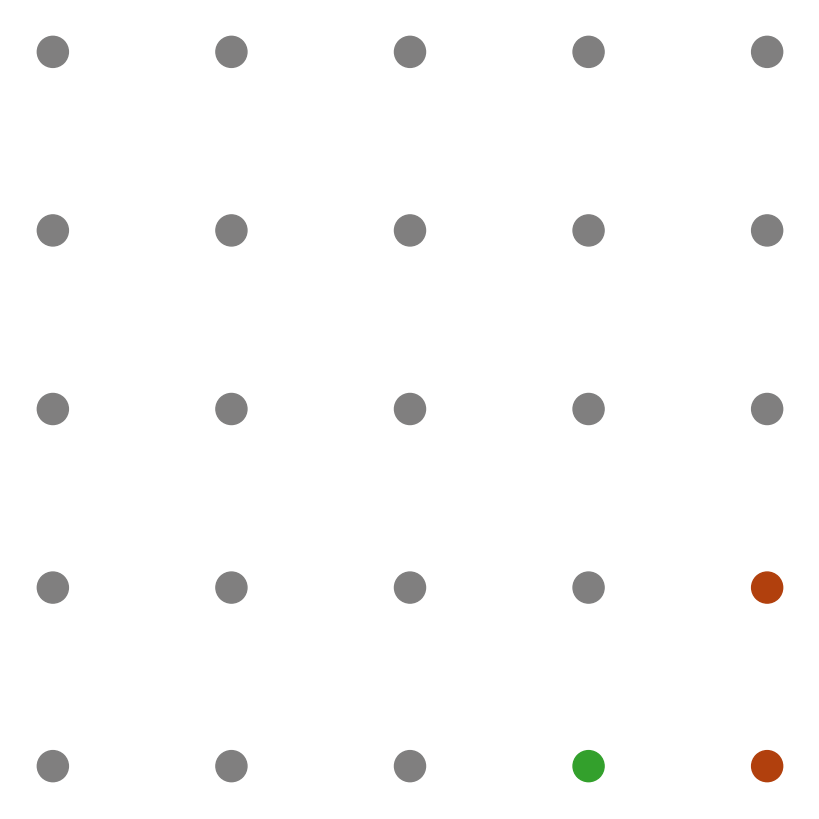

In [ ]:
# --- 3. Trees-only transparent video (MPC, 1:1, no ticks/labels/titles) ---
print("\n--- Generating MPC trees-only transparent video (1:1) ---")

import io  # assicurati che sia importato

def square_bounds_from_points(points, pad_ratio=0.06):
    """Compute square bounds around points (N,2) with small padding."""
    x_min, x_max = points[:,0].min(), points[:,0].max()
    y_min, y_max = points[:,1].min(), points[:,1].max()
    cx, cy = 0.5*(x_min+x_max), 0.5*(y_min+y_max)
    span = max(x_max - x_min, y_max - y_min)
    span = max(span, 1e-6)
    pad = max(1e-6, span * pad_ratio)
    half = 0.5*span + pad
    return (cx - half, cx + half, cy - half, cy + half)

if 'mpc' not in data_cache or data_cache['mpc']['trees'] is None or data_cache['mpc']['trees'].size == 0:
    print("No MPC data with trees found. Skipping trees-only video.")
else:
    mpc = data_cache['mpc']
    times = mpc['time']
    trees = mpc['trees']
    lambda_h = mpc['lambda_h']  # shape (T, n_trees)
    n_frames = len(times)
    n_trees = trees.shape[0]

    # Bounds 1:1, leggero padding
    x0, x1, y0, y1 = square_bounds_from_points(trees)

    # Output paths
    out_dir_png = os.path.join(baselines_dir, "trees_mpc_frames")
    os.makedirs(out_dir_png, exist_ok=True)
    output_webm_path = os.path.join(baselines_dir, "trees_mpc_transparent.webm")

    # >>> AGGIUNTA: path GIF <<<
    output_gif_path = os.path.join(baselines_dir, "trees_mpc_transparent.gif")

    # Render params
    figsize = 8      # pollici; 1:1
    dot_size = 500   # dimensione marker (regolabile)
    step = 1         # frame stride (>=1)

    # --- Durata target in secondi e FPS calcolato ---
    TARGET_SECS = 99.0
    eff_frames = (n_frames + step - 1) // step  # = ceil(n_frames/step)
    FPS = eff_frames / TARGET_SECS if eff_frames > 1 else 1.0 / TARGET_SECS
    FPS = max(1e-6, float(5))
    print(f"[Trees-only] eff_frames={eff_frames}, target={TARGET_SECS}s -> FPS={FPS:.6f}")

    # >>> AGGIUNTA: durata per frame GIF (in secondi) <<<
    gif_frame_duration = 0.12 #TARGET_SECS / max(1, eff_frames)

    # Figura completamente trasparente, niente assi
    fig_tr = plt.figure(figsize=(figsize, figsize))
    ax_tr = fig_tr.add_axes([0, 0, 1, 1])
    fig_tr.patch.set_alpha(0.0)
    fig_tr.patch.set_facecolor('none')
    ax_tr.set_facecolor('none')

    # Setup viewport
    ax_tr.set_xlim(x0, x1)
    ax_tr.set_ylim(y0, y1)
    ax_tr.set_aspect('equal', adjustable='box')
    ax_tr.set_axis_off()

    # Tentativo: writer WebM VP9 con alfa
    writer = None
    webm_ok = False
    try:
        writer = imageio.get_writer(
            output_webm_path,
            fps=FPS,                      # <-- usa FPS calcolato
            format="FFMPEG",
            codec="libvpx-vp9",
            output_params=["-pix_fmt", "yuva420p"]  # VP9 + alpha
        )
        webm_ok = True
        print("Using VP9/WEBM with alpha for transparent video.")
    except Exception as e:
        print(f"WEBM (VP9+alpha) not available ({e}). Will export PNG frames only.")

    frames_written = 0
    for k in range(0, n_frames, step):
        ax_tr.cla()
        ax_tr.set_xlim(x0, x1)
        ax_tr.set_ylim(y0, y1)
        ax_tr.set_aspect('equal', adjustable='box')
        ax_tr.set_axis_off()

        # Colora ogni albero in base alla belief corrente
        curr_colors = []
        for i in range(n_trees):
            val = lambda_h[k, i] if (lambda_h is not None and lambda_h.shape[1] > i) else 0.5
            curr_colors.append(custom_cmap(val))
        curr_colors = np.array(curr_colors)

        ax_tr.scatter(trees[:,0], trees[:,1], s=dot_size, c=curr_colors, marker='o')

        # Salva frame RGBA in buffer PNG per preservare l'alfa
        buf = io.BytesIO()
        fig_tr.savefig(buf, format='png', dpi=140, transparent=True)  # alfa on
        buf.seek(0)

        # 1) PNG frame sequence (sempre)
        png_path = os.path.join(out_dir_png, f"frame_{k:05d}.png")
        with open(png_path, "wb") as f:
            f.write(buf.getbuffer())

        # 2) WEBM VP9+alpha (se disponibile)
        if webm_ok and writer is not None:
            try:
                frame_rgba = imageio.v2.imread(buf)  # RGBA
                writer.append_data(frame_rgba)
            except Exception as e:
                print(f"Failed to append frame {k} to WEBM: {e}")
                webm_ok = False  # evita ulteriori errori
        buf.close()
        frames_written += 1

    plt.close(fig_tr)
    if writer is not None:
        try:
            writer.close()
        except Exception:
            pass

    print(f"Saved {frames_written} RGBA PNG frames to: {out_dir_png}")
    if webm_ok:
        print(f"Transparent WEBM saved to: {output_webm_path}")
    else:
        print("WEBM not created. Use the PNG frames for compositing, or encode via ffmpeg:")
        print(
            f'  ffmpeg -framerate {FPS:.6f} -i "{out_dir_png}/frame_%05d.png" '
            f'-c:v libvpx-vp9 -pix_fmt yuva420p "{output_webm_path}"'
        )

    # >>> AGGIUNTA: Creazione GIF con trasparenza 1-bit <<<
    try:
        # raccogli i frame PNG nell’ordine corretto
        png_files = sorted([p for p in os.listdir(out_dir_png) if p.endswith(".png")])
        if len(png_files) == 0:
            raise RuntimeError("No PNG frames found for GIF.")

        frames = []
        for fname in png_files:
            fpath = os.path.join(out_dir_png, fname)
            # mantieni canale alfa; imageio farà la quantizzazione in GIF (1-bit alpha)
            frames.append(imageio.v2.imread(fpath))

        # salva GIF: loop=0 (infinito), duration in secondi per frame
        imageio.mimsave(
            output_gif_path,
            frames,
            format="GIF",
            duration=gif_frame_duration,
            loop=0
        )
        print(f"Transparent-like GIF saved to: {output_gif_path}")
        print(f"[GIF] eff_frames={len(frames)}, per-frame duration={gif_frame_duration:.6f}s, total≈{len(frames)*gif_frame_duration:.3f}s")
    except Exception as e:
        print(f"Failed to create GIF: {e}")
        print("Alternative via ffmpeg (binaria trasparenza, palette ottimizzata):")
        print(
            # palette + gif con trasparenza; imposta fps coerente
            f'  ffmpeg -v warning -framerate {FPS:.6f} -i "{out_dir_png}/frame_%05d.png" '
            f'-vf "palettegen=stats_mode=full[pal];[0:v][pal]paletteuse=dither=sierra2_4a:alpha_threshold=128" '
            f'"{output_gif_path}"'
        )
